In [2]:
import pandas as pd

acc_df = pd.read_csv("train_acc.csv")
loss_df = pd.read_csv("train_loss.csv")

loss_df.columns = [col.replace(' - train_loss', '') for col in loss_df.columns]
acc_df.columns = [col.replace(' - train_acc', '') for col in acc_df.columns]

acc_cols_to_keep = ['trainer/global_step',
                 'cnn-8', 'cnn-4', 'cnn-2','cnn1',
                 'fc512', 'fc256', 'fc128', 'fc1024']
acc_df = acc_df[acc_cols_to_keep]

loss_cols_to_keep = ['trainer/global_step',
                 'cnn-8', 'cnn-4', 'cnn-2','cnn1',
                 'fc512', 'fc256', 'fc128', 'fc1024']
loss_df = loss_df[loss_cols_to_keep]



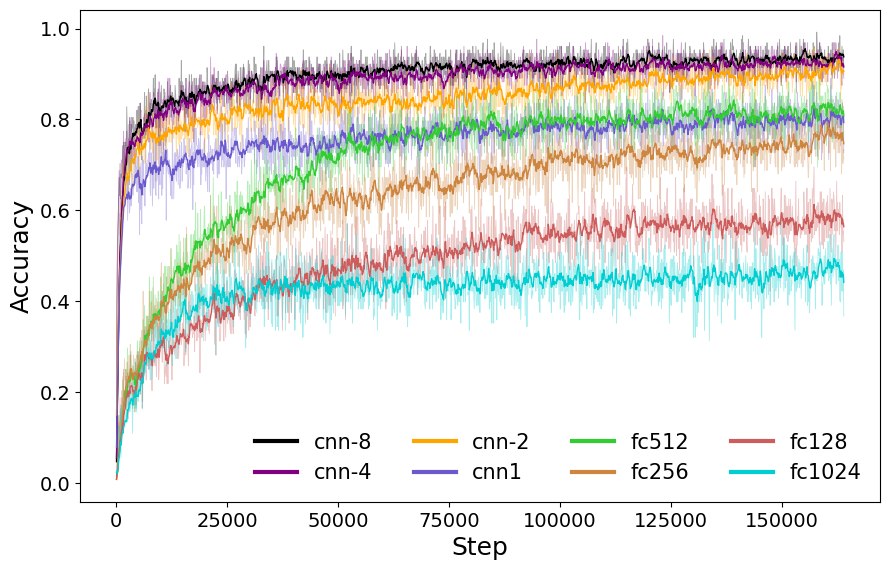

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x_col = 'trainer/global_step'
y_cols = acc_cols_to_keep

colors = ['black', 'purple', 'orange', 'slateblue', 'limegreen', 'peru', 'indianred', 'darkturquoise']
ema_span = 10

plt.figure(figsize=(10, 6))

for i in range(1, 9):
    plt.plot(acc_df[x_col], acc_df[y_cols[i]], color=colors[i-1], linewidth=0.6, alpha=0.35)

for i in range(1, 9):
    ema = acc_df[y_cols[i]].ewm(span=ema_span, adjust=False).mean()
    plt.plot(acc_df[x_col], ema, color=colors[i-1], linewidth=1)  # bold EMA

plt.xlabel('Step', fontsize=18)
plt.ylabel('Accuracy', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

handles = [Line2D([0], [0], color=colors[i-1], lw=3.0) for i in range(1, 9)]
plt.legend(handles, y_cols[1:9], ncol=4, frameon=False, fontsize=15)
plt.subplots_adjust(top=0.93)
plt.subplots_adjust(left=0.1)



plt.savefig("train_acc.png")

plt.show()


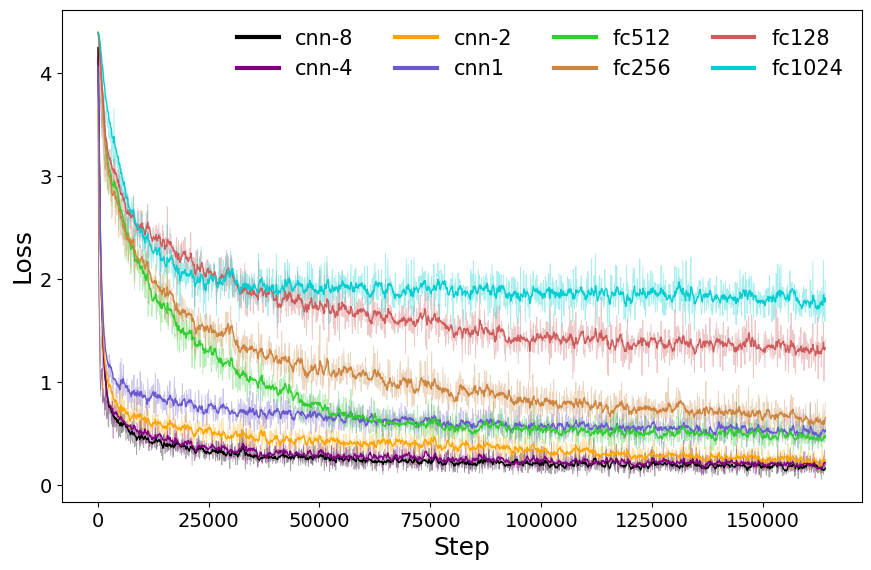

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x_col = 'trainer/global_step'
y_cols = loss_cols_to_keep

colors = ['black', 'purple', 'orange', 'slateblue', 'limegreen', 'peru', 'indianred', 'darkturquoise']
ema_span = 10

plt.figure(figsize=(10, 6))

for i in range(1, 9):
    plt.plot(loss_df[x_col], loss_df[y_cols[i]], color=colors[i-1], linewidth=0.6, alpha=0.35)

for i in range(1, 9):
    ema = loss_df[y_cols[i]].ewm(span=ema_span, adjust=False).mean()
    plt.plot(loss_df[x_col], ema, color=colors[i-1], linewidth=1)  # bold EMA

plt.xlabel('Step', fontsize=18)
plt.ylabel('Loss', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
handles = [Line2D([0], [0], color=colors[i-1], lw=3.0) for i in range(1, 9)]
plt.legend(handles, y_cols[1:9], ncol=4, frameon=False, fontsize=15)
plt.subplots_adjust(top=0.93)
plt.subplots_adjust(left=0.1)



plt.savefig("train_loss.png")

plt.show()